### Frozen vs fine-tuned

Does the ranking of encoders come from the quality of their off-the-shelf
representations, or from how well they adapt? The frozen probe isolates the first:
same mean-pooling, same logistic regression, only the encoder differs.

Reads `../results.csv`, writes `frozen_vs_finetuned.png`.

In [1]:
import sys

sys.path.insert(0, "..")
from config import RESULTS_DIR

import matplotlib.pyplot as plt
import polars as pl

# match the thesis body font (Computer Modern)
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["cmr10", "DejaVu Serif"],
        "font.monospace": ["cmtt10", "DejaVu Sans Mono"],
        "mathtext.fontset": "cm",
        "axes.unicode_minus": False,
    }
)

d = (
    pl.read_csv(RESULTS_DIR / "results.csv")
    .filter(pl.col("corpus") == "twd")  # chrono rows would pollute the means
    .group_by("model")
    .agg(
        pl.col("macro_f1").mean().alias("m"), pl.col("macro_f1").std(ddof=0).alias("s")
    )
)
m = dict(zip(d["model"], d["m"]))
s = dict(zip(d["model"], d["s"]))

PRETTY = {
    "roberta-large": "RoBERTa-large",
    "roberta-base": "RoBERTa-base",
    "flang-roberta": "FLANG-RoBERTa",
    "bert-large-uncased": "BERT-large",
    "flang-bert": "FLANG-BERT",
    "bert-base-uncased": "BERT-base",
}
rows = sorted(PRETTY, key=lambda k: -m[k])

C:\Users\vpati\AppData\Local\Temp\ipykernel_41352\484789733.py:3: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(figsize=(9.5, 5.2))


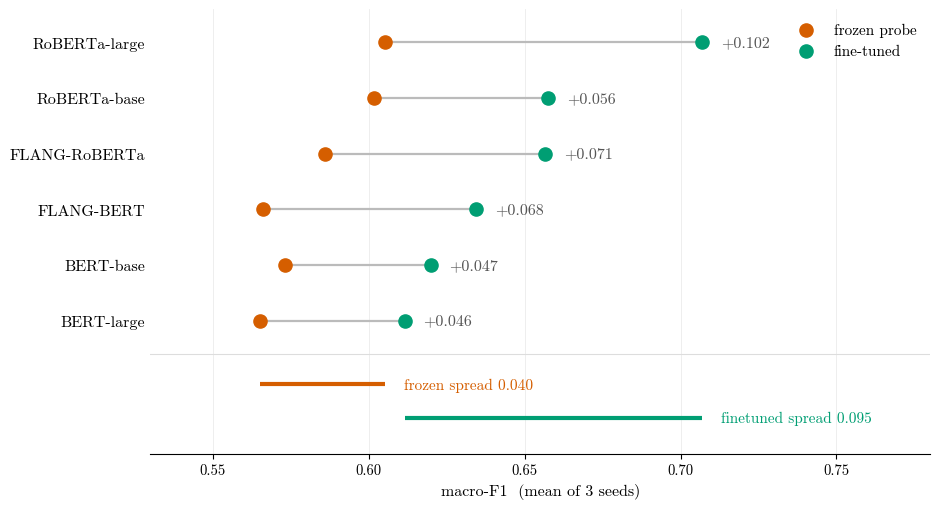

In [2]:
FROZ, FINE = "#D55E00", "#009E73"  # Okabe-Ito, safe under red-green colour blindness

fig, ax = plt.subplots(figsize=(9.5, 5.2))

for i, k in enumerate(rows):
    y = len(rows) - 1 - i
    a, b = m["frozen:" + k], m[k]
    ax.plot([a, b], [y, y], color="#bbb", lw=1.6, zorder=1, solid_capstyle="round")
    ax.scatter(a, y, s=90, color=FROZ, zorder=3)
    ax.scatter(b, y, s=90, color=FINE, zorder=3)
    ax.text(b + 0.006, y, f"+{b - a:.3f}", va="center", fontsize=11.5, color="#555")

# the two spreads, as spans under the axis
fz = [m["frozen:" + k] for k in rows]
ft = [m[k] for k in rows]
for vals, colour, lbl, yy in [
    (fz, FROZ, "frozen", -1.15),
    (ft, FINE, "finetuned", -1.75),
]:
    ax.plot([min(vals), max(vals)], [yy, yy], color=colour, lw=3, solid_capstyle="butt")
    ax.text(
        max(vals) + 0.006,
        yy,
        f"{lbl} spread {max(vals) - min(vals):.3f}",
        va="center",
        fontsize=11,
        color=colour,
    )

ax.set_yticks(range(len(rows)))
ax.set_yticklabels([PRETTY[k] for k in reversed(rows)], fontsize=11.5)
ax.set_ylim(-2.4, len(rows) - 0.4)
ax.set_xlim(0.53, 0.78)
ax.set_xlabel("macro-F1  (mean of 3 seeds)", fontsize=11.5)
ax.tick_params(axis="x", labelsize=10.5)
ax.axhline(-0.6, color="#ddd", lw=0.8)

ax.scatter([], [], s=90, color=FROZ, label="frozen probe")
ax.scatter([], [], s=90, color=FINE, label="fine-tuned")
ax.legend(loc="upper right", frameon=False, fontsize=11)

for sp in ("top", "right", "left"):
    ax.spines[sp].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.grid(axis="x", alpha=0.25, lw=0.6)
ax.set_axisbelow(True)

fig.tight_layout()
fig.savefig("frozen_vs_finetuned.png", dpi=200, bbox_inches="tight", facecolor="white")
fig.savefig("frozen_vs_finetuned.pdf", bbox_inches="tight", facecolor="white")

### What it shows

- Off the shelf, all six encoders sit within **0.040** macro-F1 of each other.
- Fine-tuned, they spread over **0.095** -- 2.4x wider.
- RoBERTa-large and RoBERTa-base are 0.004 apart frozen, 0.049 apart fine-tuned.

So the separation between encoders is largely created by fine-tuning rather than
present beforehand.

Care with the stronger claim: Spearman rank correlation between the two orderings
is 0.94 (p = 0.00, n = 6) -- a positive relationship, not none. The
defensible statement is about the spread, not about the rankings being unrelated.
